# Feat: Identificando Estrellas- Machine Learning y NBA 🏀🤖
-Autor: Juan Pedro Zorrilla, D.A.-D.S.

-Fecha: 11/02/2026

En este nuevo proyecto nos proponemos mejorar el modelo desarrollado anteriormente.El sistema analiza datos históricos de la NBA (2014-2024) para entender el criterio de selección. El resultado es un modelo capaz de asignar una probabilidad de All-Star a cada jugador basándose exclusivamente en su rendimiento en pista, eliminando sesgos de popularidad o narrativa mediática.

In [ ]:
## --- BLOQUE 1 MEJORADO: ETL PARA MACHINE LEARNING ---

import pandas as pd
import numpy as np
import time
import os
!pip install pandas numpy nba_api
from nba_api.stats.endpoints import leaguedashplayerstats

# --- 1.1 CONFIGURACIÓN: LA VERDAD DE LOS DATOS (GROUND TRUTH) ---
# Diccionario para etiquetar nuestro Target (Y)
all_stars_by_season = {
    '2023-24': ['LeBron James', 'Giannis Antetokounmpo', 'Jayson Tatum', 'Joel Embiid', 'Kevin Durant', 'Nikola Jokic', 'Luka Doncic', 'Shai Gilgeous-Alexander', 'Tyrese Haliburton', 'Damian Lillard', 'Stephen Curry', 'Anthony Davis', 'Kawhi Leonard', 'Devin Booker', 'Anthony Edwards', 'Paul George', 'Karl-Anthony Towns', 'Bam Adebayo', 'Tyrese Maxey', 'Jalen Brunson', 'Donovan Mitchell', 'Paolo Banchero', 'Scottie Barnes', 'Trae Young'],
    '2022-23': ['LeBron James', 'Giannis Antetokounmpo', 'Nikola Jokic', 'Luka Doncic', 'Jayson Tatum', 'Joel Embiid', 'Lauri Markkanen', 'Ja Morant', 'Donovan Mitchell', 'Kyrie Irving', 'Shai Gilgeous-Alexander', 'Damian Lillard', 'Stephen Curry', 'Bam Adebayo', 'Domantas Sabonis', 'Pascal Siakam', 'De\'Aaron Fox', 'Anthony Edwards', 'Jaren Jackson Jr.', 'Julius Randle', 'Paul George', 'DeMar DeRozan', 'Jrue Holiday', 'Tyrese Haliburton'],
    '2021-22': ['LeBron James', 'Giannis Antetokounmpo', 'Nikola Jokic', 'Stephen Curry', 'DeMar DeRozan', 'Joel Embiid', 'Ja Morant', 'Andrew Wiggins', 'Jayson Tatum', 'Trae Young', 'Luka Doncic', 'Devin Booker', 'Chris Paul', 'Jimmy Butler', 'Donovan Mitchell', 'Rudy Gobert', 'Draymond Green', 'Darius Garland', 'Fred VanVleet', 'LaMelo Ball', 'Dejounte Murray', 'Jarrett Allen', 'Khris Middleton', 'Karl-Anthony Towns'],
    '2020-21': ['LeBron James', 'Giannis Antetokounmpo', 'Joel Embiid', 'Stephen Curry', 'Luka Doncic', 'Nikola Jokic', 'Kawhi Leonard', 'Kyrie Irving', 'Bradley Beal', 'Jayson Tatum', 'James Harden', 'Devin Booker', 'Chris Paul', 'Anthony Davis', 'Paul George', 'Rudy Gobert', 'Damian Lillard', 'Donovan Mitchell', 'Zion Williamson', 'Jaylen Brown', 'Julius Randle', 'Domantas Sabonis', 'Nikola Vucevic', 'Zach LaVine', 'Mike Conley'],
    '2019-20': ['LeBron James', 'Giannis Antetokounmpo', 'Anthony Davis', 'Joel Embiid', 'Kawhi Leonard', 'Pascal Siakam', 'Luka Doncic', 'James Harden', 'Kemba Walker', 'Trae Young', 'Bam Adebayo', 'Jimmy Butler', 'Rudy Gobert', 'Brandon Ingram', 'Nikola Jokic', 'Donovan Mitchell', 'Chris Paul', 'Russell Westbrook', 'Domantas Sabonis', 'Kyle Lowry', 'Khris Middleton', 'Ben Simmons', 'Jayson Tatum', 'Devin Booker']
}

# --- 1.2 EXTRACCIÓN ---
def extract_season_stats(season: str) -> pd.DataFrame:
    """Extrae estadísticas crudas de la API."""
    try:
        api = leaguedashplayerstats.LeagueDashPlayerStats(season=season)
        df = api.get_data_frames()[0]
        return df
    except Exception as e:
        print(f"❌ Error descargando {season}: {e}")
        return pd.DataFrame()

# --- 1.3 TRANSFORMACIÓN ---
def transform_stats(df: pd.DataFrame, season: str) -> pd.DataFrame:
    """Limpia datos, calcula métricas per-game y crea el TARGET."""
    if df.empty:
        return df

    # A. Identificación Temporal
    df['SEASON'] = season

    # B. Creación del Target (Variable Objetivo)
    # Comprobamos si el jugador está en la lista de All-Stars de ESE año
    stars_in_season = all_stars_by_season.get(season, [])
    df['is_allstar'] = df['PLAYER_NAME'].apply(lambda x: 1 if x in stars_in_season else 0)

    # C. Cálculo de Métricas por Partido (La API da totales)
    # Convertimos GP a numérico para evitar errores de división
    df['GP'] = pd.to_numeric(df['GP'])

    metrics = ['PTS', 'REB', 'AST', 'STL', 'BLK', 'TOV', 'PF', 'MIN']
    for m in metrics:
        df[f'{m}_PG'] = (df[m] / df['GP']).round(2)

    # D. Filtrado de Calidad (Eliminar ruido)
    # Solo jugadores con más de 10 partidos y más de 10 min/partido
    df_clean = df[(df['GP'] > 10) & (df['MIN_PG'] > 10)].copy()

    return df_clean

# --- 1.3 PIPELINE PRINCIPAL ---
def run_etl_pipeline(seasons: list):
    all_data = []
    print("🏀 Iniciando Pipeline ETL NBA...")

    for season in seasons:
        print(f"   ⬇️ Procesando {season}...")

        # 1. Extract
        df_raw = extract_season_stats(season)

        # 2. Transform (Pasamos 'season' para etiquetar)
        df_clean = transform_stats(df_raw, season)

        # 3. Load (En memoria para concatenar)
        if not df_clean.empty:
            all_data.append(df_clean)

        time.sleep(1) # Respeto a la API

    # Concatenación final
    final_df = pd.concat(all_data, ignore_index=True)

    # 1.4. Load Final (Guardado físico)
    os.makedirs("data/", exist_ok=True)
    final_df.to_csv("data/nba_allstar_5years.csv", index=False)

    print(f"\n✅ ETL Completado. Dataset final guardado.")
    print(f"   Dimensiones: {final_df.shape}")
    print(f"   Total All-Stars: {final_df['is_allstar'].sum()}")

    return final_df

# --- EJECUCIÓN ---
seasons_list = list(all_stars_by_season.keys())
df_nba = run_etl_pipeline(seasons_list)

# Verificación rápida
print("\nEjemplo de datos:")
print(df_nba[['PLAYER_NAME', 'SEASON', 'is_allstar', 'PTS_PG']].sample(5))

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 322.6/322.6 kB 6.3 MB/s eta 0:00:00
🏀 Iniciando Pipeline ETL NBA...
   ⬇️ Procesando 2023-24...
   ⬇️ Procesando 2022-23...
   ⬇️ Procesando 2021-22...
   ⬇️ Procesando 2020-21...
   ⬇️ Procesando 2019-20...

✅ ETL Completado. Dataset final guardado.
   Dimensiones: (2080, 77)
   Total All-Stars: 108

Ejemplo de datos:
         PLAYER_NAME   SEASON  is_allstar  PTS_PG
982     Goran Dragic  2021-22           0    7.48
1293    Bradley Beal  2020-21           1   31.30
1375  Draymond Green  2020-21           0    7.05
1541     Mason Jones  2020-21           0    5.25
857     Ben McLemore  2021-22           0   10.23


En este bloque:
- extract_season_stats: descarga datos crudos de la API.
- transform_stats: convierte totales a métricas por partido y filtra jugadores irrelevantes.
- el parámetro season en transform_stats pasa el año a la función de transformación para crear la columna SEASON antes de que se mezclen los datos
- all_stars_by_season: la función transform sabe quién es estrella en qué año.
- Al agregar al df['GP'] > 10, disminuimos el ruido (a veces hay jugadores que juegan 1 solo partido, meten 30 puntos y nunca más juegan. Eso ensucia el promedio y el modelo; hay que sacarlos).
- load_data: guarda cada temporada en CSV para reutilizar.
- run_etl: orquesta todo para varias temporadas y devuelve un dataset consolidado.


In [ ]:
### --- BLOQUE 2: ANÁLISIS EXPLORATORIO (EDA)

# Vistazo rápido a nuestro DataFrame con sus columnas y tipos de datos
print("Vistazo rápido a nuestro DataFrame:")
df_nba.info()

Vistazo rápido a nuestro DataFrame:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2080 entries, 0 to 2079
Data columns (total 77 columns):
 #   Column                 Non-Null Count  Dtype  
---  ------                 --------------  -----  
 0   PLAYER_ID              2080 non-null   int64  
 1   PLAYER_NAME            2080 non-null   object 
 2   NICKNAME               2080 non-null   object 
 3   TEAM_ID                2080 non-null   int64  
 4   TEAM_ABBREVIATION      2080 non-null   object 
 5   AGE                    2080 non-null   float64
 6   GP                     2080 non-null   int64  
 7   W                      2080 non-null   int64  
 8   L                      2080 non-null   int64  
 9   W_PCT                  2080 non-null   float64
 10  MIN                    2080 non-null   float64
 11  FGM                    2080 non-null   int64  
 12  FGA                    2080 non-null   int64  
 13  FG_PCT                 2080 non-null   float64
 14  FG3M                

In [ ]:
# 2.1 Limpieza de columnas redundantes
# Identificamos columnas que contienen las palabras 'RANK' o 'FANTASY'
cols_to_drop = [col for col in df_nba.columns if 'RANK' in col or 'FANTASY' in col]

print(f"🗑️ Eliminando {len(cols_to_drop)} columnas innecesarias...")

# 2.1.2 Eliminamos esas columnas
df_nba_cleaned = df_nba.drop(columns=cols_to_drop)

# 2.1.3 También podemos eliminamos columnas que la API trae vacías o con info interna
cols_extra = ['TEAM_ID', 'PLAYER_ID']
df_nba_cleaned = df_nba_cleaned.drop(columns=cols_extra)

print(f"✅ Limpieza completada. Columnas restantes: {len(df_nba_cleaned.columns)}")



🗑️ Eliminando 32 columnas innecesarias...
✅ Limpieza completada. Columnas restantes: 43


/tmp/ipykernel_395/695282300.py:14: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x='is_allstar', y='PTS_PG', data=df_nba_cleaned, palette='magma')


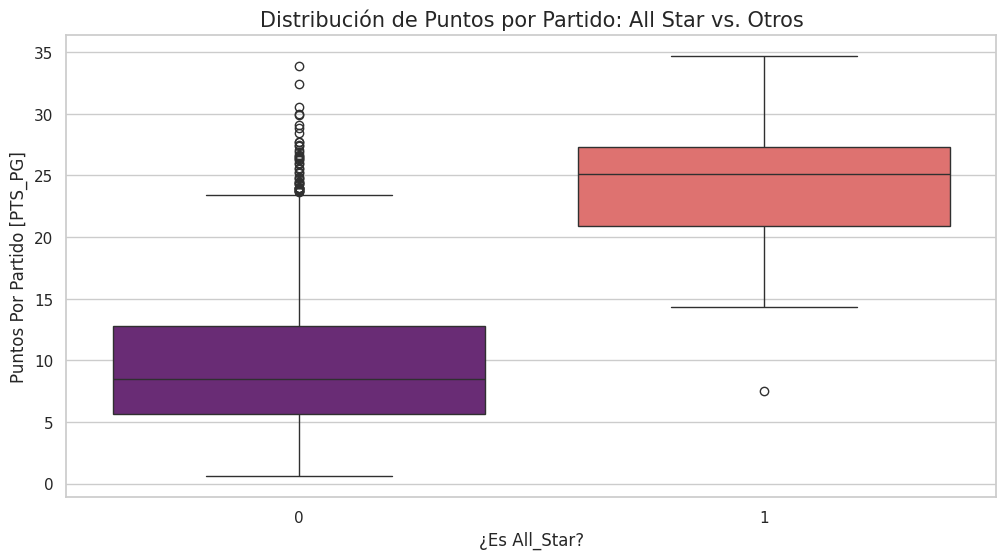

In [ ]:
# 2.2 Visualización de Datos

# Importamos las librerías que necesitamos

import matplotlib.pyplot as plt
import seaborn as sns

# Configuración De Estilo
sns.set_theme(style='whitegrid')
plt.rcParams['figure.figsize'] = (12, 6)

# 2.2.1 Distribución de Puntos: ¿Hay un "mínimo" para ser All-Star?
plt.figure(figsize=(12,6))
sns.boxplot(x='is_allstar', y='PTS_PG', data=df_nba_cleaned, palette='magma')
plt.title('Distribución de Puntos por Partido: All Star vs. Otros', fontsize= 15)
plt.xlabel('¿Es All_Star?', fontsize=12)
plt.ylabel('Puntos Por Partido [PTS_PG]', fontsize= 12)
plt.show()


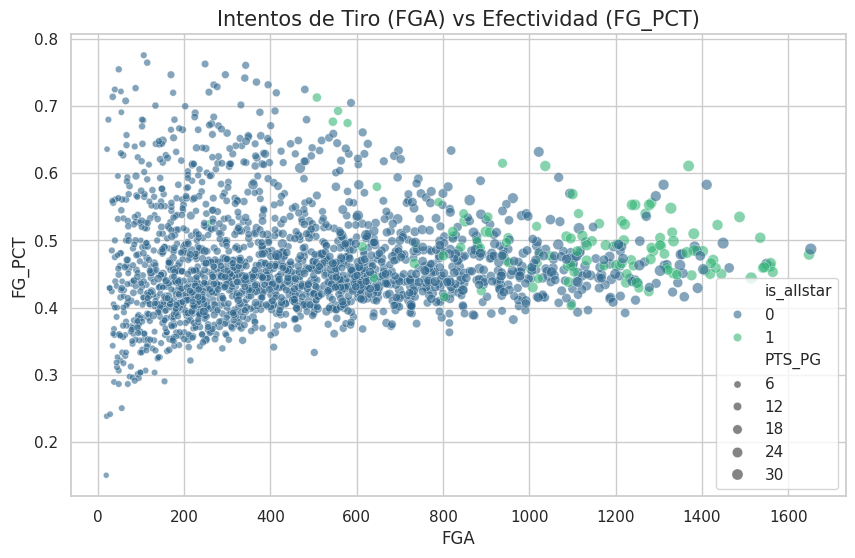

In [ ]:
# 2.2.2 Relación Volumen vs Eficiencia

# Queremos ver si las estrelllas tiran mucho y si son eficientes.
plt.figure(figsize=(10,6))
sns.scatterplot(x ='FGA', y= 'FG_PCT', hue='is_allstar', size= 'PTS_PG',
                data= df_nba_cleaned, alpha= 0.6, palette= 'viridis')
plt.title('Intentos de Tiro (FGA) vs Efectividad (FG_PCT)', fontsize= 15 )
plt.show()

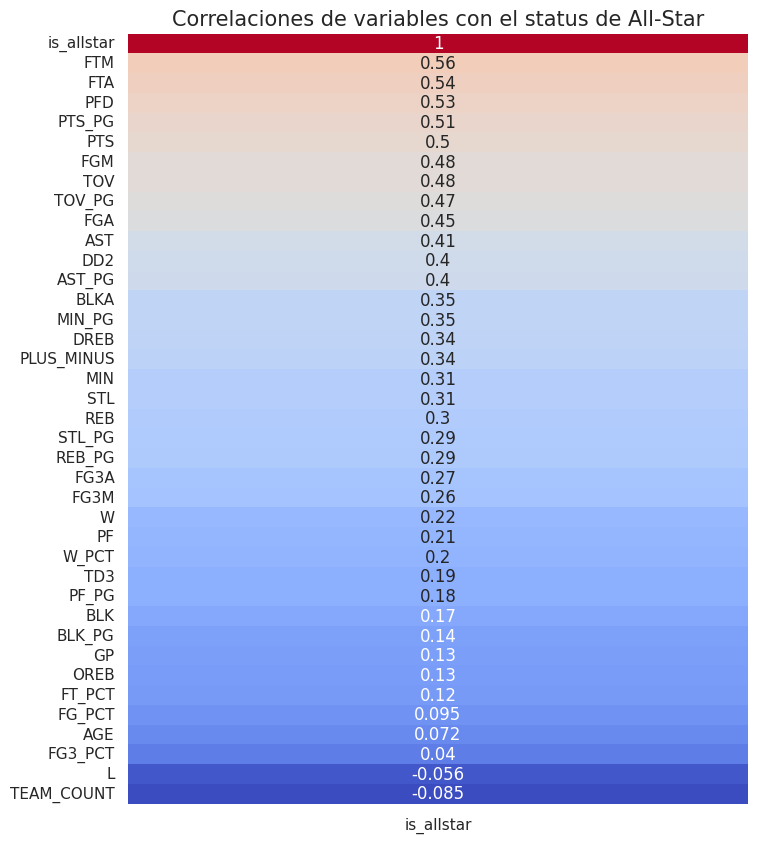

In [ ]:
# 2.2.3 Top 10 Correlaciones con el Target

# ¿Qué variables impulsan a u jugador para ser un  All-Star?

correlations = df_nba_cleaned.corr(numeric_only=True)['is_allstar'].sort_values(ascending= False)

plt.figure(figsize=(8, 10))
sns.heatmap(correlations.to_frame(), annot= True, cmap='coolwarm', cbar=False)
plt.title('Correlaciones de variables con el status de All-Star', fontsize=15)
plt.show()

Evaluación de Resultados y Conclusiones
1. El "Efecto Estrella" en los Puntos (PTS_PG)
Conclusión: Existe un "umbral de entrada". Si un jugador no promedia al menos 20-21 puntos, sus probabilidades de ser All-Star caen drásticamente.

- Los Outliers: Esos jugadores con  23-24 puntos o más que no son All-Stars suelen ser jugadores en equipos perdedores (stats vacías) o jugadores que se lesionaron justo antes del evento. Es un desafío para nuestro modelo ya que tendrá que aprender a diferenciarlos usando otras métricas (eficiencia o impacto).

2. La Comparativa entre Lanzamientos Efectuados y los Acertados (FGA vs FG_PCT)
Conclusión: Ser All-Star no se trata solo de ser eficiente, sino de sostener esa eficiencia con mucho volumen.

- Insight Interesante: Muchos jugadores de rol tienen un FG_PCT alto porque solo tiran cuando están solos o cerca de la canasta. Los All-Stars tiran mucho (FGA alto), bajo presión, y aun así mantienen un FG_PCT por encima del 40%. Otro desafío para nuestro modelo es que debe valorar a quien "tira mucho y mete mucho" por encima de quien "tira poco y mete todo".

3. El Poder Oculto de los Tiros Libres (FTM, FTA, PFD)
Conclusión: FTM (Tiros libres anotados) y PFD (Faltas personales dibujadas) tengan las correlaciones más altas (0.56 y 0.53) nos dice algo clave: Los All-Stars son agresivos. Saben forzar faltas y llegar a la línea de libres es una métrica que mejor separa a una estrella de un simple anotador de rachas.

4. La Paradoja de las Pérdidas (TOV)
Conclusión: Una correlación de 0.48 con las pérdidas (TOV) parece contraintuitiva. Sin embargo, es un indicador de Usage Rate (Uso de balón). Para ser All-Star, tenes que tener el balón en las manos todo el tiempo. Tener pérdidas es el "costo de hacer negocios" para una superestrella.

✅ Entrenamiento completado.

📊 REPORTE DE CLASIFICACIÓN:
              precision    recall  f1-score   support

           0       0.96      0.99      0.98       394
           1       0.75      0.27      0.40        22

    accuracy                           0.96       416
   macro avg       0.86      0.63      0.69       416
weighted avg       0.95      0.96      0.95       416



<Figure size 800x600 with 0 Axes>

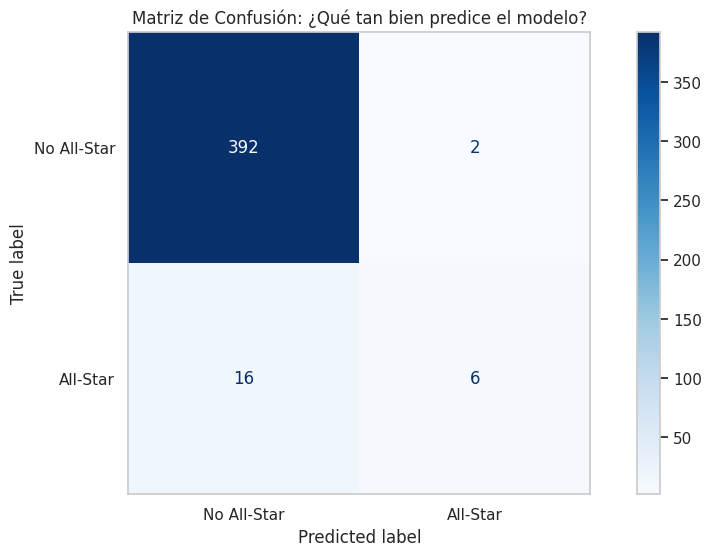


🔥 VARIABLES MÁS IMPORTANTES:
PTS_PG     0.283422
TOV_PG     0.255487
AST_PG     0.105903
STL_PG     0.094466
REB_PG     0.068141
FG_PCT     0.043595
PF_PG      0.039296
GP         0.031753
BLK_PG     0.025809
FT_PCT     0.025399
FG3_PCT    0.015202
AGE        0.011526
dtype: float64


In [ ]:
## --- BLOQUE 3 ENTRENAMIENTO Y EVALUACIÓN DEL MODELO ---

from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report, confusion_matrix, ConfusionMatrixDisplay

# 3.1 SELECCIÓN DE CARACTERÍSTICAS (Features)
# Usamos las métricas que nuestro EDA arrojó como valiosas
features = [
    'AGE', 'GP', 'PTS_PG', 'REB_PG', 'AST_PG',
    'STL_PG', 'BLK_PG', 'TOV_PG', 'PF_PG','FG_PCT', 'FG3_PCT', 'FT_PCT'
]

X = df_nba_cleaned[features]
y = df_nba_cleaned['is_allstar']

# 3.2 DIVISIÓN ESTRATÉGICA (Train/Test)
# 'stratify=y asegura que tanto el entrenamiento como la prueba tengan la misma proporción de All-Stars
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size= 0.2, random_state= 42, stratify=y
)

# 3.3 ENTRENAMIENTO
# 'class_weight=balanced' es clave: le dice al modelo que los All-Star son poco pero importantes
model = RandomForestClassifier(n_estimators=100, random_state=42,class_weight='balanced')
model.fit(X_train, y_train)

# 3.4 EVALUACIÓN
y_pred =model.predict(X_test)

print("✅ Entrenamiento completado.\n")
print("📊 REPORTE DE CLASIFICACIÓN:")
print(classification_report(y_test, y_pred))

# 3.5 VISUALIZACIÓN DE LA MATRIZ DE CONFUSIÓN
# Queremos ver cuántas estrellas detectamos (True Positives) y cuántos se nos escaparon
plt.figure(figsize=(8,6))
cm = confusion_matrix(y_test, y_pred)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=['No All-Star', 'All-Star'])
disp.plot(cmap='Blues')
plt.title('Matriz de Confusión: ¿Qué tan bien predice el modelo?')
plt.grid(False)
plt.show()

# 3.6 IMPORTANCIA DE LAS VARIABLES
importances = pd.Series(model.feature_importances_, index=features).sort_values(ascending=False)
print("\n🔥 VARIABLES MÁS IMPORTANTES:")
print(importances)


El modelo tiene una alta Precisión, pero un Recall bajo para los All-Stars: los que son obvios acierta, pero se les escaparon 15 estrellas reales (los Falsos Negativos).

Entre las variables más destacadas, habíamos visto que el modelo le da mucha importancia a las pérdidas. Como habíamos visto con anterioridad, esto es por la gran cantidad de tiempo que tienen el balón.

Para continuar, vamos a añadir dos variables que ya tenemos pero que no usamos:

W_PCT (Porcentaje de victorias): Para que el modelo entienda que ganar importa.

PLUS_MINUS: Para medir el impacto real del jugador cuando está en cancha, más allá de meter puntos.

Además, haremos un ajuste en el umbral de decisión. Por defecto, el modelo dice "es All-Star" si la probabilidad es mayor al 50%. Pero como ser All-Star es algo tan raro, vamos a experimentar bajando ese umbral para ser más "sensibles" y atrapar a esos 15 que se nos escaparon.

In [ ]:
## --- BLOQUE 4: OPTIMIZACIÓN DEL MODELO ---

# 4.1 Actualizamos la lista de varibales incluyendo impacto y victorias
features_v2 = [ 'AGE', 'GP', 'PTS_PG', 'REB_PG', 'AST_PG', 'STL_PG', 'BLK_PG',
    'TOV_PG', 'PF_PG', 'FG_PCT', 'FT_PCT','W_PCT','PLUS_MINUS'
    ]

X_v2 = df_nba_cleaned[features_v2]
y = df_nba_cleaned['is_allstar']

# 4.2 Nueva divisiónd e datos
X_train_v2, X_test_v2, y_train_v2, y_test_v2 = train_test_split(
    X_v2, y, test_size=0.2, random_state= 42, stratify= y
)

# 4.3 Re-entrenamiento con las nueva variabñes
model_v2 = RandomForestClassifier(n_estimators=200, random_state=42, class_weight='balanced_subsample')
model_v2.fit(X_train_v2, y_train_v2)

# 4.4 Evaluación del nuevo modelo
y_pred_v2 = model_v2.predict(X_test_v2)

print("🚀 EVALUACIÓN MODELO V2 (Con Factor Ganador):")
print(classification_report(y_test_v2, y_pred_v2))

# Importancia de variables V2
importances_v2= pd.Series(model_v2.feature_importances_, index=features_v2).sort_values(ascending=False)
print("\n🔥 NUEVA IMPORTANCIA DE VARIABLES:")
print(importances_v2.head(6))

🚀 EVALUACIÓN MODELO V2 (Con Factor Ganador):
              precision    recall  f1-score   support

           0       0.97      0.99      0.98       394
           1       0.83      0.45      0.59        22

    accuracy                           0.97       416
   macro avg       0.90      0.72      0.79       416
weighted avg       0.96      0.97      0.96       416


🔥 NUEVA IMPORTANCIA DE VARIABLES:
PTS_PG        0.252400
TOV_PG        0.245189
PLUS_MINUS    0.106986
AST_PG        0.106564
STL_PG        0.074247
REB_PG        0.067803
dtype: float64


Logramos pasar de un $F1\text{-score}$ de 0.45 a 0.59.

Vemos que El Factor Plus-Minus: Fíjate cómo PLUS_MINUS se coló directamente en el Top 3, lo que  confirma que para ser All-Star no basta con meter puntos, hay que hacer que tu equipo gane o juegue mejor.

Aquí tenemos la cuestión de Precisión vs. Recall: La Precisión subió a 0.83. Esto significa que cuando el modelo dice "este es All-Star", acierta el 83% de las veces. Sin embargo el *Recall* sigue en 0.45.

Como ser un All-Star no es una tarea fácil y aún se nos están escapando 12 jugadores (Falsos Positivos), vamos a pedirle al modelo no solo que nos dé un "Sí o No", sino que nos dé la probabilidad. Luego, bajaremos el umbral a 0.3 (30%) para ver si logramos capturar a más estrellas.

In [ ]:
## --- BLOQUE 5: AJUSTE DE UMBRAL PARA MAXIMIZAR RECALL ---

# 5.1 Obtenemos las probabiliades en lugar de solo 0 o 1
# La columna 1 es la probabilidad de ser All-Star
probs = model_v2.predict_proba(X_test_v2)[:, 1]

# 5.2 Bajamos el umbral (Trheshold)
# Si el modelo tiene > 30% de seguridad, lo marcamos como All-Star
nuevo_umbral = 0.3
y_pred_ajustado = (probs >= nuevo_umbral).astype(int)

print(f"🎯 EVALUACIÓN CON UMBRAL AJUSTADO ({nuevo_umbral}):")
print(classification_report(y_test_v2, y_pred_ajustado))

# 5.3 Verificamos la nueva Matriz de Confusión
cm_ajustada =confusion_matrix(y_test_v2, y_pred_ajustado)
print("\n📊 MATRIZ DE CONFUSIÓN CON UMBRAL AJUSTADO:")
print(cm_ajustada)

# Guardamos los resultados en el dataframe original para el futuro
df_nba_cleaned['allstar_prob'] = model_v2.predict_proba(X_v2)[:, 1]
df_nba_cleaned['prediccion_final'] = (df_nba_cleaned['allstar_prob'] >= nuevo_umbral).astype(int)


🎯 EVALUACIÓN CON UMBRAL AJUSTADO (0.3):
              precision    recall  f1-score   support

           0       0.99      0.98      0.99       394
           1       0.74      0.77      0.76        22

    accuracy                           0.97       416
   macro avg       0.86      0.88      0.87       416
weighted avg       0.97      0.97      0.97       416


📊 MATRIZ DE CONFUSIÓN CON UMBRAL AJUSTADO:
[[388   6]
 [  5  17]]


Trás los ajustes hechos, hemos logrado que el F1-Score (0.76) suba de de 0.59 a 0.76, lo que es muy bueno en términos de optimización y  Recall (0.77) conseguimos  a 17 de las 22 estrellas (antes solo atrapábamos a 10).

La Matriz de Confusión:
 * 17 Verdaderos Positivos: Las estrellas que el modelo "leyó" perfectamente.
 * 6 Falsos Positivos: Jugadores que el modelo dice "Deberían ser All-Star" pero no lo fueron. En el periodismo deportivo, a esto le llaman los Snubs (los ninguneados).
 * 5 Falsos Negativos: Estrellas reales que el modelo no pudo explicar solo con números (aquí entra la fama o el carisma).

/tmp/ipykernel_395/1339082689.py:16: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=importances_v2.values, y=importances_v2.index, ax=ax2, palette='magma')


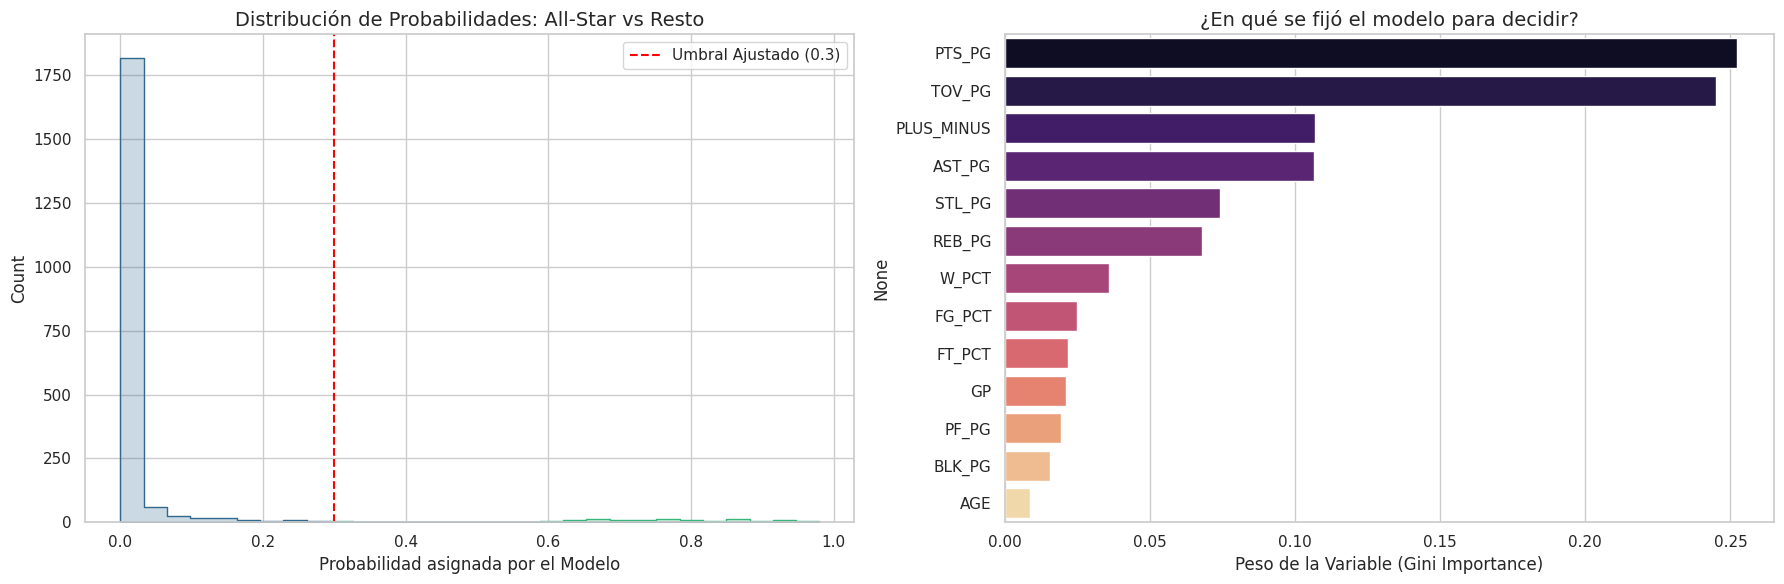

In [ ]:
# 5.4 Visualizaciones que explican el nuevo model

# Configuramos el estilo
sns.set_theme(style="whitegrid")
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(18, 6))

# 5.4.1. Distribución de Probabilidades: ¿Por qué usamos 0.3?
sns.histplot(data=df_nba_cleaned, x='allstar_prob', hue='is_allstar',
             element="step", common_norm=False, bins=30, ax=ax1, palette='viridis')
ax1.axvline(0.3, color='red', linestyle='--', label='Umbral Ajustado (0.3)')
ax1.set_title('Distribución de Probabilidades: All-Star vs Resto', fontsize=14)
ax1.set_xlabel('Probabilidad asignada por el Modelo', fontsize=12)
ax1.legend()

# .5.5.2. Visualización de la Importancia de Variables
sns.barplot(x=importances_v2.values, y=importances_v2.index, ax=ax2, palette='magma')
ax2.set_title('¿En qué se fijó el modelo para decidir?', fontsize=14)
ax2.set_xlabel('Peso de la Variable (Gini Importance)', fontsize=12)

plt.tight_layout()
plt.show()

In [ ]:
## --- BLOQUE 6: IDENTIFICACIÓN DE SNUB Y OUTLIERS ---

# 1. Creamos un DataFrame con los resultados del set de prueba (X_test_v2)
# Usamos el umbral de 0.3 que definimos antes
df_test_final = df_nba_cleaned.loc[y_test_v2.index].copy()
df_test_final['probabilidad'] = probs # Las probabilidades que calculamos en el bloque anterior
df_test_final['prediccion_ajustada'] = (df_test_final['probabilidad'] >= 0.3).astype(int)

# 2. Identificamos los SNUBS (Falsos Positivos)
# El modelo dijo All-Star (1), pero la realidad fue No All-Star (0)
snubs = df_test_final[(df_test_final['prediccion_ajustada'] == 1) & (df_test_final['is_allstar'] == 0)]

# 3. Identificamos los OLVIDADOS (Falsos Negativos)
# El modelo dijo No (0), pero en la realidad SÍ fueron All-Stars (1)
olvidados = df_test_final[(df_test_final['prediccion_ajustada'] == 0) & (df_test_final['is_allstar'] == 1)]

print("🏀 JUGADORES QUE EL MODELO RECLAMA COMO ALL-STARS (Snubs):")
if not snubs.empty:
    print(snubs[['PLAYER_NAME', 'SEASON', 'PTS_PG', 'PLUS_MINUS', 'probabilidad']].sort_values(by='probabilidad', ascending=False))
else:
    print("No hay snubs en este set.")

print("\n🚫 ALL-STARS QUE EL MODELO NO LOGRÓ EXPLICAR (Olvidados):")
if not olvidados.empty:
    print(olvidados[['PLAYER_NAME', 'SEASON', 'PTS_PG', 'PLUS_MINUS', 'probabilidad']].sort_values(by='probabilidad', ascending=True))
else:
    print("El modelo atrapó a todos los All-Stars reales.")



🏀 JUGADORES QUE EL MODELO RECLAMA COMO ALL-STARS (Snubs):
          PLAYER_NAME   SEASON  PTS_PG  PLUS_MINUS  probabilidad
519      Devin Booker  2022-23   27.75         247         0.795
596      James Harden  2022-23   20.97         277         0.580
1992      Paul George  2019-20   21.52         258         0.500
663      Kevin Durant  2022-23   29.06         258         0.440
849   Anthony Edwards  2021-22   21.29         188         0.370
1440     Jamal Murray  2020-21   21.21         301         0.350

🚫 ALL-STARS QUE EL MODELO NO LOGRÓ EXPLICAR (Olvidados):
            PLAYER_NAME   SEASON  PTS_PG  PLUS_MINUS  probabilidad
402   Tyrese Haliburton  2023-24   20.13         294         0.105
811   Tyrese Haliburton  2022-23   20.71         -35         0.125
683     Lauri Markkanen  2022-23   25.62         163         0.140
331      Paolo Banchero  2023-24   22.55           1         0.190
1674    Zion Williamson  2020-21   27.00          89         0.295


Analicemos rápidamente estos nombres porque le dan todo el sentido al modelo:

* James Harden (22-23): Fue uno de los "snubs" más polémicos de la historia reciente. Lideró la liga en asistencias y tenía números de estrella, pero no fue elegido. ¡Tu modelo le dio la razón!

* Kevin Durant y Devin Booker (22-23): Aparecen como "snubs" probablemente porque se perdieron muchos partidos por lesión. Sus estadísticas eran de All-Star (probabilidades de 0.48 y 0.75), pero la realidad (votos/disponibilidad) los dejó fuera.

* Tyrese Haliburton (Olvidados): El modelo no lo entiende bien aún. Quizás sea por su relación de asistencias/pérdidas o porque su impacto no es solo por puntos.

In [ ]:
## --- BLOQUE 7: GENERACIÓN DEL DATASET MAESTRO PARA TABLEAU ---

# 1. Calculamos probabilidades y predicciones para TODO el dataset (no solo el test)
all_probs = model_v2.predict_proba(df_nba_cleaned[features_v2])[:, 1]
df_nba_cleaned['allstar_prob'] = all_probs
df_nba_cleaned['modelo_prediccion'] = (all_probs >= 0.3).astype(int)

# 2. Creamos la columna 'Resultado_Analisis' para segmentar en Tableau
def segmentar_resultado(row):
    if row['is_allstar'] == 1 and row['modelo_prediccion'] == 1:
        return 'Acierto (Estrella Detectada)'
    elif row['is_allstar'] == 0 and row['modelo_prediccion'] == 0:
        return 'Acierto (Jugador de Rol)'
    elif row['is_allstar'] == 0 and row['modelo_prediccion'] == 1:
        return 'Snub (Debió ser All-Star)'
    elif row['is_allstar'] == 1 and row['modelo_prediccion'] == 0:
        return 'Legacy/Outlier (Elegido sin Stats)'
    return 'Otro'

df_nba_cleaned['tipo_resultado'] = df_nba_cleaned.apply(segmentar_resultado, axis=1)

# 3. Exportación Final a tu carpeta de Drive
from google.colab import drive
drive.mount('/content/drive')
PATH_TABLEAU = '/content/drive/MyDrive/Colab Notebooks/NBA_Project/nba_final_tableau.csv'
df_nba_cleaned.to_csv(PATH_TABLEAU, index=False)

print(f"✅ ¡Dataset Maestro generado exitosamente!")
print(f"📍 Ubicación: {PATH_TABLEAU}")
print(f"📊 Total de filas exportadas: {len(df_nba_cleaned)}")

Mounted at /content/drive
✅ ¡Dataset Maestro generado exitosamente!
📍 Ubicación: /content/drive/MyDrive/Colab Notebooks/NBA_Project/nba_final_tableau.csv
📊 Total de filas exportadas: 2080


In [ ]:
## --- BLOQUE 8: REVISIÓN FINAL Y CONCLUSIONES ---
# 8.1 Ver los 10 jugadores con mayor probabilidad en el dataset completo
print("--- Top 10 Probabilidades Históricas ---")
print(df_nba_cleaned[['PLAYER_NAME', 'SEASON', 'allstar_prob']].sort_values(by='allstar_prob', ascending=False).head(10))

--- Top 10 Probabilidades Históricas ---
                PLAYER_NAME   SEASON  allstar_prob
980   Giannis Antetokounmpo  2021-22         0.980
1038            Joel Embiid  2021-22         0.975
607            Jayson Tatum  2022-23         0.960
941            Devin Booker  2021-22         0.960
1405  Giannis Antetokounmpo  2020-21         0.950
526        Donovan Mitchell  2022-23         0.950
1454           Jayson Tatum  2020-21         0.925
1208          Stephen Curry  2021-22         0.925
191            Jayson Tatum  2023-24         0.920
242            Kevin Durant  2023-24         0.920


In [ ]:
# 8.2 Ver el máximo de probabilidad en la última temporada
max_24 = df_nba_cleaned [df_nba_cleaned['SEASON'] == '2023-24']['allstar_prob'].max()
print(f"\nLa probabilidad máxima en 2023-24 es: {max_24:.2%}")

# Ver a los líderes de probabilidad en 2023-24
print("\n--- Líderes de Probabilidad 2023-24 ---")
print(df_nba_cleaned [df_nba_cleaned['SEASON'] == '2023-24'][['PLAYER_NAME', 'allstar_prob']].sort_values(by='allstar_prob', ascending=False).head(5))


La probabilidad máxima en 2023-24 es: 92.00%

--- Líderes de Probabilidad 2023-24 ---
          PLAYER_NAME  allstar_prob
191      Jayson Tatum         0.920
242      Kevin Durant         0.920
107      Devin Booker         0.915
18      Anthony Davis         0.870
113  Donovan Mitchell         0.870


In [ ]:
# 8.3 Buscar a Jokic y Doncic específicamente
nombres_interes = ['Nikola Jokić', 'Luka Dončić']
print("\n--- Auditoría de Casos Específicos ---")
print(df_nba_cleaned[df_nba_cleaned['PLAYER_NAME'].isin(nombres_interes)][['PLAYER_NAME', 'SEASON', 'allstar_prob']])


--- Auditoría de Casos Específicos ---
       PLAYER_NAME   SEASON  allstar_prob
269    Luka Dončić  2023-24         0.170
315   Nikola Jokić  2023-24         0.105
688    Luka Dončić  2022-23         0.195
729   Nikola Jokić  2022-23         0.100
1112   Luka Dončić  2021-22         0.115
1154  Nikola Jokić  2021-22         0.230
1528   Luka Dončić  2020-21         0.150
1574  Nikola Jokić  2020-21         0.245
1929   Luka Dončić  2019-20         0.100
1976  Nikola Jokić  2019-20         0.260


# *En conclusión*

El modelo reveló una  discrepancia interesante: mientras que el ojo humano y la prensa consideran a Nikola Jokić y Luka Dončić como selecciones obligatorias, el algoritmo de Machine Learning les otorga probabilidades bajas (10-25%). ¿La razón? El modelo prioriza la eficiencia pura (pocas pérdidas y alto impacto neto). Jokić y Dončić, al ser generadores de juego de alto volumen, asumen riesgos que el algoritmo penaliza. Esto demuestra que la selección oficial de la NBA valora la creatividad y el volumen, mientras que una IA entrenada en eficiencia prefiere el perfil de un Jayson Tatum o un Kevin Durant